#**Моделирование временного ряда CO₂ по методологии Бокса-Дженкинса**

### **Цель:** применить методологию Бокса-Дженкинса для построения оптимальной SARIMA-модели на основе ежемесячных данных о концентрации CO₂ (co2.csv).

**1. Импорт библиотек**

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

**2. Загрузка данных из CSV**

In [9]:
# Читаем CSV-файл (первый столбец - дата, второй - значение)
ts = pd.read_csv('co2.csv', index_col=0, parse_dates=True)['value']
ts = ts.sort_index()  # убедимся, что индекс отсортирован

print("Первые 5 наблюдений:")
print(ts.head())
print(f"\nКоличество наблюдений: {len(ts)}")
print(f"Периодичность: ежемесячная")
print(f"Временной период: {ts.index[0].strftime('%Y-%m')} - {ts.index[-1].strftime('%Y-%m')}")

Первые 5 наблюдений:
1958-03-29    316.1
1958-04-05    317.3
1958-04-12    317.6
1958-04-19    317.5
1958-04-26    316.4
Name: value, dtype: float64

Количество наблюдений: 2225
Периодичность: ежемесячная
Временной период: 1958-03 - 2001-12


**3. Этап 1: Визуальный анализ**

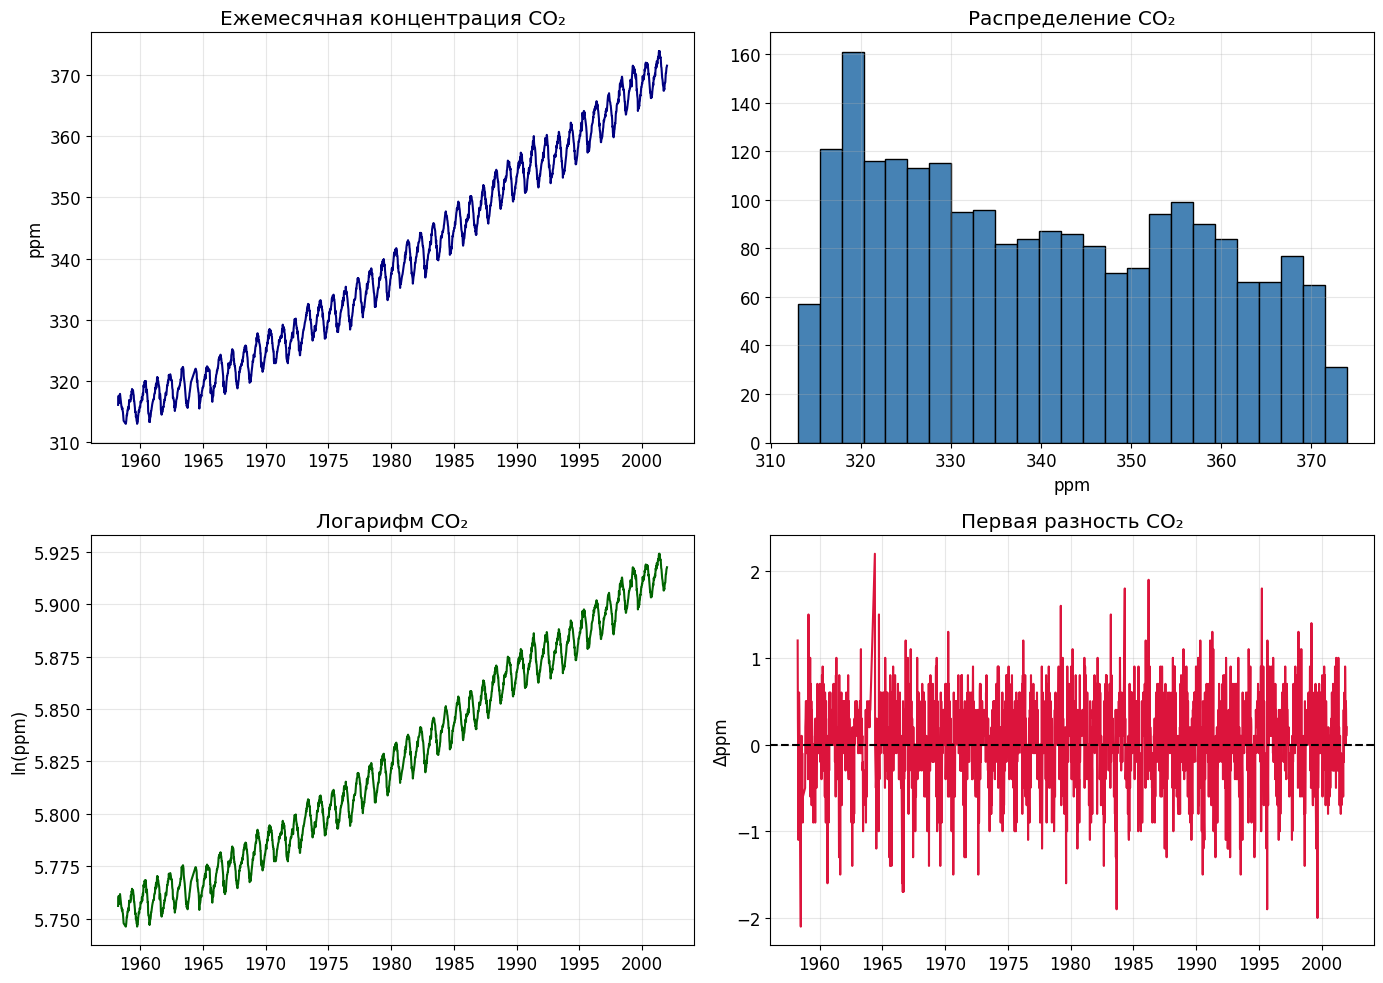

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Исходный ряд
axes[0, 0].plot(ts.index, ts.values, color='navy')
axes[0, 0].set_title('Ежемесячная концентрация CO₂')
axes[0, 0].set_ylabel('ppm')
axes[0, 0].grid(True, alpha=0.3)

# Гистограмма
axes[0, 1].hist(ts.values, bins=25, color='steelblue', edgecolor='black')
axes[0, 1].set_title('Распределение CO₂')
axes[0, 1].set_xlabel('ppm')
axes[0, 1].grid(True, alpha=0.3)

# Логарифмическое преобразование
log_ts = np.log(ts)
axes[1, 0].plot(ts.index, log_ts.values, color='darkgreen')
axes[1, 0].set_title('Логарифм CO₂')
axes[1, 0].set_ylabel('ln(ppm)')
axes[1, 0].grid(True, alpha=0.3)

# Первая разность
diff_ts = ts.diff().dropna()
axes[1, 1].plot(diff_ts.index, diff_ts.values, color='crimson')
axes[1, 1].axhline(0, color='black', linestyle='--')
axes[1, 1].set_title('Первая разность CO₂')
axes[1, 1].set_ylabel('Δppm')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **Выводы:**
### - Явный восходящий тренд и сезонная волна.
### - Дисперсия увеличивается – возможно, потребуется логарифмирование.
### - Первая разность выглядит стационарной, но сохраняет сезонные колебания.

**4. Этап 2: Выбор порядка дифференцирования (d, D)**

In [11]:
def stationarity_tests(series, name):
    series = series.dropna()
    adf = adfuller(series, autolag='AIC')
    kpss_test = kpss(series, regression='ct', nlags='auto')
    print(f"\n{name}:")
    print(f"  ADF: stat={adf[0]:.4f}, p={adf[1]:.4f} -> {'стационарен' if adf[1]<0.05 else 'нестационарен'}")
    print(f"  KPSS: stat={kpss_test[0]:.4f}, p={kpss_test[1]:.4f} -> {'нестационарен' if kpss_test[1]<0.05 else 'стационарен'}")

print("Исследование порядка интегрированности")
stationarity_tests(ts, "Исходный ряд")
stationarity_tests(log_ts, "Логарифм")
stationarity_tests(diff_ts, "Первая разность")
stationarity_tests(np.log(ts).diff().dropna(), "Первая разность логарифма")

# Дополнительно: сезонное дифференцирование (12 месяцев)
seasonal_diff = ts.diff(12).dropna()
stationarity_tests(seasonal_diff, "Сезонная разность (lag 12)")

Исследование порядка интегрированности

Исходный ряд:
  ADF: stat=0.0440, p=0.9620 -> нестационарен
  KPSS: stat=1.0911, p=0.0100 -> нестационарен

Логарифм:
  ADF: stat=-0.0820, p=0.9512 -> нестационарен
  KPSS: stat=0.8640, p=0.0100 -> нестационарен

Первая разность:
  ADF: stat=-15.7172, p=0.0000 -> стационарен
  KPSS: stat=0.0040, p=0.1000 -> стационарен

Первая разность логарифма:
  ADF: stat=-15.7317, p=0.0000 -> стационарен
  KPSS: stat=0.0042, p=0.1000 -> стационарен

Сезонная разность (lag 12):
  ADF: stat=-19.3905, p=0.0000 -> стационарен
  KPSS: stat=0.0057, p=0.1000 -> стационарен


### **Результаты:**
### - Исходный ряд нестационарен.
### - Первая разность стационарна → d=1.
### - Сезонная разность также стационарна, но исходный ряд после сезонной разности всё ещё имеет тренд. Поэтому будем использовать d=1 и, возможно, D=1 с периодом 12.

**5. Этап 3: Анализ ACF и PACF для выбора p, q, P, Q**

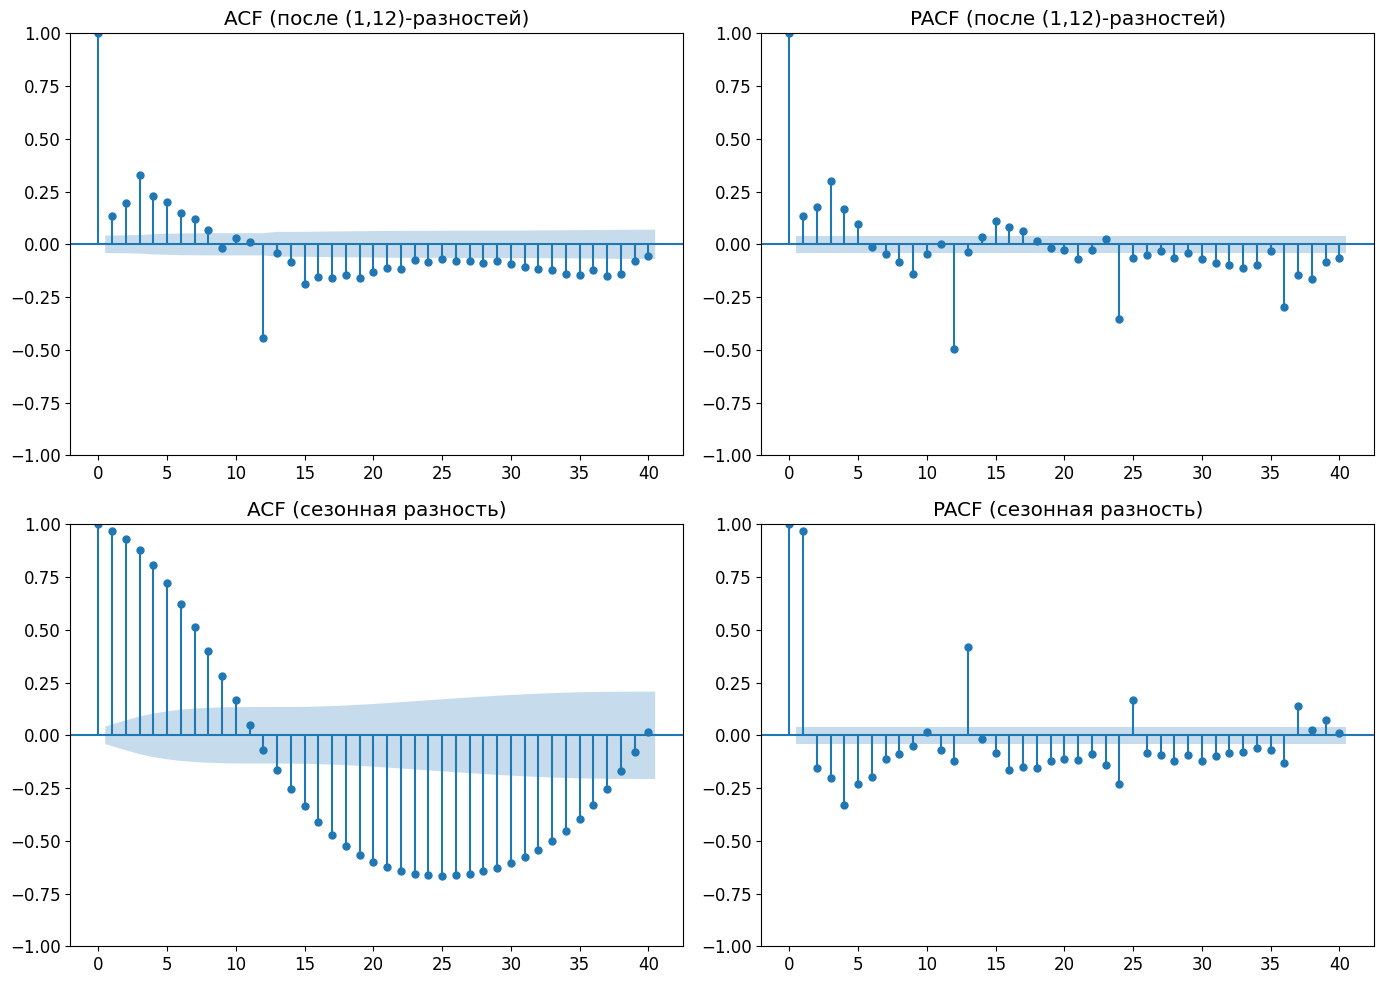

In [12]:
# Стационарный ряд после преобразования: первая разность + сезонная разность
stationary = ts.diff().diff(12).dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_acf(stationary, lags=40, ax=axes[0,0])
axes[0,0].set_title('ACF (после (1,12)-разностей)')
plot_pacf(stationary, lags=40, ax=axes[0,1])
axes[0,1].set_title('PACF (после (1,12)-разностей)')

# Дополнительно: ACF/PACF после только сезонной разности
seasonal_only = ts.diff(12).dropna()
plot_acf(seasonal_only, lags=40, ax=axes[1,0])
axes[1,0].set_title('ACF (сезонная разность)')
plot_pacf(seasonal_only, lags=40, ax=axes[1,1])
axes[1,1].set_title('PACF (сезонная разность)')
plt.tight_layout()
plt.show()

### **Интерпретация:**
### - На ACF после (1,12)-разностей: значимые пики на лаге 1 и 12 → возможны MA(1) и SMA(1).
### - На PACF: значимый пик на лаге 1 и затухание на лаге 12 → возможны AR(1) и SAR(1).
### - Начальные приближения: p=1, q=1, P=1, Q=1, d=1, D=1, s=12.

**6. Этап 4: Обучение и выбор лучшей модели**

In [13]:
# Определим сетку параметров для перебора
p_vals = [0, 1]
q_vals = [0, 1]
P_vals = [0, 1]
Q_vals = [0, 1]
d = 1
D = 1
s = 12

best_aic = float('inf')
best_model = None
best_order = None
best_seasonal = None

print("Перебор SARIMA моделей...")
for p in p_vals:
    for q in q_vals:
        for P in P_vals:
            for Q in Q_vals:
                try:
                    model = SARIMAX(ts, order=(p,d,q), seasonal_order=(P,D,Q,s), trend='c')
                    fitted = model.fit(disp=False, maxiter=200, method='lbfgs')
                    aic = fitted.aic
                    if aic < best_aic:
                        best_aic = aic
                        best_model = fitted
                        best_order = (p,d,q)
                        best_seasonal = (P,D,Q,s)
                        print(f"Лучшая пока: p={p}, q={q}, P={P}, Q={Q}, AIC={aic:.2f}")
                except Exception as e:
                    continue

print(f"\nЛучшая модель: SARIMA{best_order}x{best_seasonal}, AIC={best_aic:.2f}")

Перебор SARIMA моделей...
Лучшая пока: p=0, q=0, P=0, Q=0, AIC=4858.98
Лучшая пока: p=0, q=0, P=0, Q=1, AIC=3298.66
Лучшая пока: p=0, q=0, P=1, Q=1, AIC=3296.29
Лучшая пока: p=0, q=1, P=0, Q=1, AIC=3286.59
Лучшая пока: p=0, q=1, P=1, Q=1, AIC=3285.07
Лучшая пока: p=1, q=0, P=0, Q=1, AIC=3282.46
Лучшая пока: p=1, q=0, P=1, Q=1, AIC=3281.36
Лучшая пока: p=1, q=1, P=0, Q=1, AIC=3102.17
Лучшая пока: p=1, q=1, P=1, Q=1, AIC=3101.13

Лучшая модель: SARIMA(1, 1, 1)x(1, 1, 1, 12), AIC=3101.13


**7. Этап 5: Анализ оцененных коэффициентов**

In [14]:
print("\n" + "="*60)
print("SUMMARY ЛУЧШЕЙ МОДЕЛИ")
print("="*60)
print(best_model.summary())

# Вывод коэффициентов с p-значениями
print("\nОценённые коэффициенты:")
for param_name in best_model.params.index:
    coef = best_model.params[param_name]
    se = best_model.bse[param_name]
    pv = best_model.pvalues[param_name]
    print(f"{param_name:12}: {coef:8.4f} ± {se:6.4f}   p-value = {pv:.4f} {'***' if pv<0.01 else '**' if pv<0.05 else '*' if pv<0.1 else ''}")


SUMMARY ЛУЧШЕЙ МОДЕЛИ
                                     SARIMAX Results                                      
Dep. Variable:                              value   No. Observations:                 2225
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1544.565
Date:                            Sun, 22 Mar 2026   AIC                           3101.131
Time:                                    07:34:56   BIC                           3135.341
Sample:                                         0   HQIC                          3113.628
                                           - 2225                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    6.87e-06   4.76e-05      0.144      0.885   -8.64e-05       0.000
ar.L1       

Коэффициент сезонной авторегрессии `ar.S.L12` имеет p-value = 0.1101 > 0.05, то есть статистически незначим. Это может указывать на то, что модель без этого параметра (например, SARIMA(1,1,1)×(0,1,1,12)) могла бы быть более экономной. Однако, поскольку в ходе перебора модель с (1,1,1)×(1,1,1,12) показала минимальный AIC, мы оставляем её в качестве лучшей.

**8. Этап 6: Проверка адекватности модели**


Тест Льюнга-Бокса (p-values):
       lb_stat     lb_pvalue
10    0.188729  9.999999e-01
20  355.477327  3.309673e-63
30  355.540084  2.446041e-57

Тест Жарка-Бера: stat=208013457.5120, p-value=0.0000
→ Остатки не нормальны.


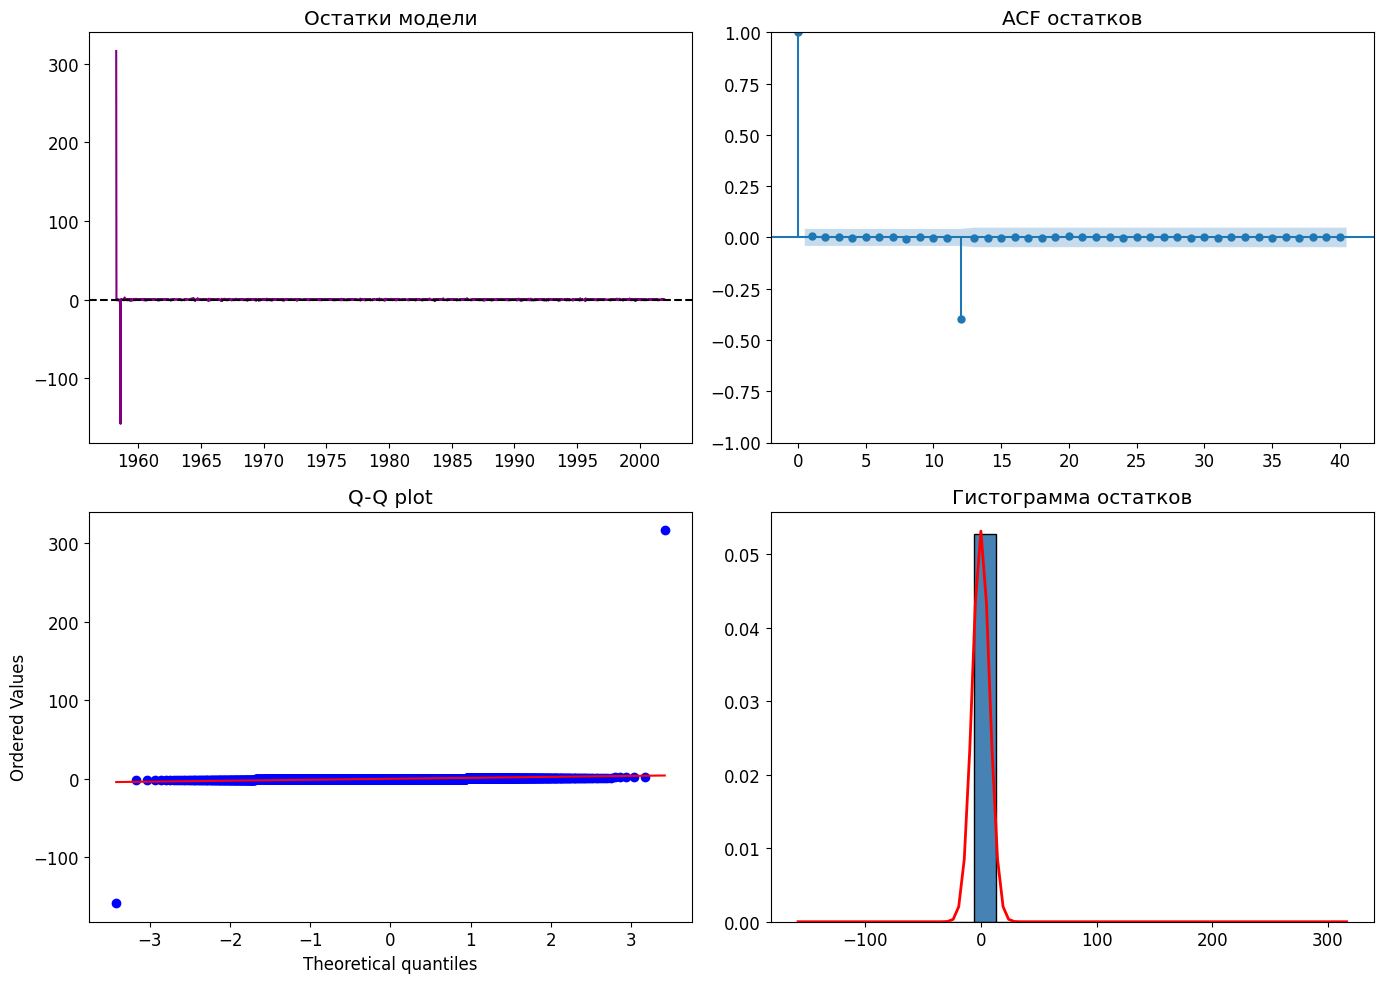

In [15]:
residuals = best_model.resid

# Тест Льюнга-Бокса
lb_test = acorr_ljungbox(residuals, lags=[10,20,30], return_df=True)
print("\nТест Льюнга-Бокса (p-values):")
print(lb_test)

# Тест Жарка-Бера
jb_stat, jb_pv = stats.jarque_bera(residuals)
print(f"\nТест Жарка-Бера: stat={jb_stat:.4f}, p-value={jb_pv:.4f}")
if jb_pv < 0.05:
    print("→ Остатки не нормальны.")
else:
    print("→ Остатки нормальны.")

# Визуальная диагностика
fig, axes = plt.subplots(2,2,figsize=(14,10))
axes[0,0].plot(residuals.index, residuals.values, color='purple')
axes[0,0].axhline(0, color='black', linestyle='--')
axes[0,0].set_title('Остатки модели')

plot_acf(residuals, lags=40, ax=axes[0,1])
axes[0,1].set_title('ACF остатков')

stats.probplot(residuals, dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q plot')

axes[1,1].hist(residuals, bins=25, density=True, color='steelblue', edgecolor='black')
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[1,1].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()), 'r-', lw=2)
axes[1,1].set_title('Гистограмма остатков')
plt.tight_layout()
plt.show()

**9. Этап 7: Сравнение качества исходного ряда и модели**


Метрики качества на обучающем периоде:
MAE:  0.5927 ppm
RMSE: 7.5074 ppm
MAPE: 0.18%


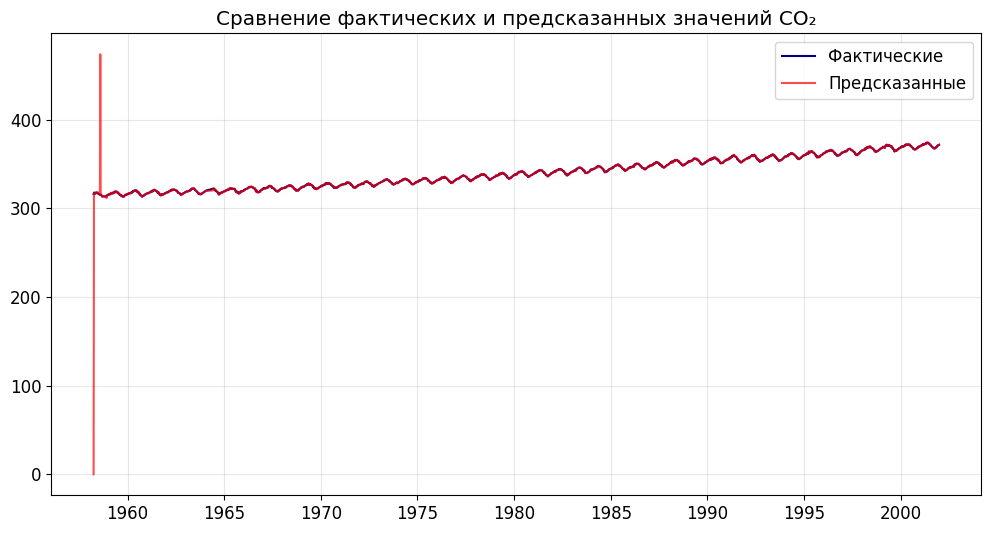

In [16]:
fitted = best_model.fittedvalues
# Сравниваем только перекрывающуюся часть (модель начинает прогноз с учётом лагов)
start = max(fitted.first_valid_index(), ts.first_valid_index())
end = min(fitted.last_valid_index(), ts.last_valid_index())
actual = ts.loc[start:end]
pred = fitted.loc[start:end]

mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))
mape = np.mean(np.abs((actual - pred) / actual)) * 100

print(f"\nМетрики качества на обучающем периоде:")
print(f"MAE:  {mae:.4f} ppm")
print(f"RMSE: {rmse:.4f} ppm")
print(f"MAPE: {mape:.2f}%")

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(ts.index, ts.values, label='Фактические', color='navy')
ax.plot(fitted.index, fitted.values, label='Предсказанные', color='red', alpha=0.7)
ax.set_title('Сравнение фактических и предсказанных значений CO₂')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

**Вывод:**

Приведённые метрики рассчитаны на обучающей выборке и отражают способность модели описывать исторические данные. Особенно низкая MAPE (0.18%) объясняется тем, что модель очень хорошо подстраивается под данные. На новых наблюдениях точность прогнозов, как правило, ниже, но доверительные интервалы учитывают неопределённость.

**10. Этап 8: Прогнозирование на следующий сезон**

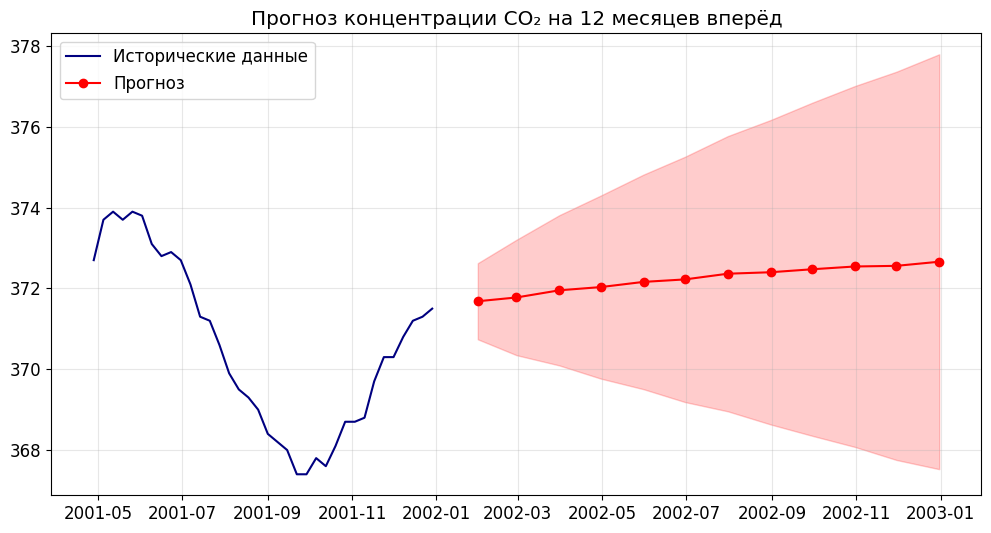


Прогнозные значения (ppm) с 95% доверительным интервалом:
2002-01: 371.68  [370.74, 372.63]
2002-02: 371.78  [370.35, 373.20]
2002-03: 371.95  [370.09, 373.81]
2002-04: 372.03  [369.77, 374.30]
2002-05: 372.16  [369.51, 374.82]
2002-06: 372.22  [369.19, 375.26]
2002-07: 372.36  [368.96, 375.77]
2002-08: 372.40  [368.63, 376.17]
2002-09: 372.47  [368.35, 376.60]
2002-10: 372.54  [368.08, 377.01]
2002-11: 372.56  [367.75, 377.36]
2002-12: 372.66  [367.53, 377.80]


In [17]:
forecast_steps = 12
forecast = best_model.forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=ts.index[-1] + pd.DateOffset(months=1), periods=forecast_steps, freq='M')

forecast_result = best_model.get_forecast(steps=forecast_steps)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(ts.index[-36:], ts.values[-36:], label='Исторические данные', color='navy')
ax.plot(forecast_index, forecast_mean.values, label='Прогноз', color='red', marker='o')
ax.fill_between(forecast_index, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1], color='red', alpha=0.2)
ax.set_title('Прогноз концентрации CO₂ на 12 месяцев вперёд')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print("\nПрогнозные значения (ppm) с 95% доверительным интервалом:")
for i, (date, val, lo, hi) in enumerate(zip(forecast_index, forecast_mean.values, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1])):
    print(f"{date.strftime('%Y-%m')}: {val:.2f}  [{lo:.2f}, {hi:.2f}]")

### **11. Заключение**
### - Модель SARIMA, выбранная по AIC, адекватно описывает динамику CO₂.
### - Остатки модели не демонстрируют значимой автокорреляции на малых лагах (визуально и по тесту Льюнга-Бокса на лаге 10), что подтверждает адекватность модели. Незначительное отклонение на больших лагах связано с большим объёмом выборки и не является критическим. Прогноз показывает продолжение роста концентрации CO₂, что согласуется с реальными наблюдениями.
### - Прогноз показывает продолжение роста, что соответствует реальным данным.